## *Data Loading & exploration :*



In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [255]:
mydata = pd.read_csv('premier-league-matches.csv')

In [256]:
df = pd.DataFrame(mydata)

In [257]:
df.shape

(12026, 8)

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12026 entries, 0 to 12025
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Season_End_Year  12026 non-null  int64 
 1   Wk               12026 non-null  int64 
 2   Date             12026 non-null  object
 3   Home             12026 non-null  object
 4   HomeGoals        12026 non-null  int64 
 5   AwayGoals        12026 non-null  int64 
 6   Away             12026 non-null  object
 7   FTR              12026 non-null  object
dtypes: int64(4), object(4)
memory usage: 751.8+ KB


In [259]:
df.head(10)

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A
5,1993,1,1992-08-15,Ipswich Town,1,1,Aston Villa,D
6,1993,1,1992-08-15,Everton,1,1,Sheffield Weds,D
7,1993,1,1992-08-15,Southampton,0,0,Tottenham,D
8,1993,1,1992-08-15,Chelsea,1,1,Oldham Athletic,D
9,1993,1,1992-08-16,Nott'ham Forest,1,0,Liverpool,H


In [260]:
df.describe()

,Season_End_Year,Wk,HomeGoals,AwayGoals
count,12026.000000,12026.000000,12026.000000,12026.000000
mean,2007.713620,19.730501,1.524364,1.142525
std,9.072559,11.123916,1.306417,1.133930
min,1993.000000,1.000000,0.000000,0.000000
25%,2000.000000,10.000000,1.000000,0.000000
50%,2008.000000,20.000000,1.000000,1.000000
75%,2016.000000,29.000000,2.000000,2.000000
max,2023.000000,42.000000,9.000000,9.000000


In [261]:
df.dtypes

,0
Season_End_Year,int64
Wk,int64
Date,object
Home,object
HomeGoals,int64
AwayGoals,int64
Away,object
FTR,object


# *Data Cleaning :*

In [262]:
df.rename(columns={
    'Home': 'home_team',
    'Away': 'away_team',
    'FTR': 'result'
}, inplace=True)

df.head()

,Season_End_Year,Wk,Date,home_team,HomeGoals,AwayGoals,away_team,result
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


### convert  'Date'  column to datetime format :

In [263]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Season_End_Year,int64
Wk,int64
Date,datetime64[ns]
home_team,object
HomeGoals,int64
AwayGoals,int64
away_team,object
result,object


In [264]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()


,season_end_year,wk,date,home_team,homegoals,awaygoals,away_team,result
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


checking for null values :

In [265]:
df.isnull().sum()

,0
season_end_year,0
wk,0
date,0
home_team,0
homegoals,0
awaygoals,0
away_team,0
result,0


checking for duplicated values :

In [266]:
df.duplicated().sum()

np.int64(0)

# Feature selection  & exploratory Data Analysis:

> Add blockquote



In [267]:
df['totalgoals'] = df['homegoals'] + df['awaygoals']
df['totalgoals']

,totalgoals
0,3
1,3
2,3
3,6
4,6
...,...
12021,1
12022,3
12023,3
12024,5


In [268]:
df.head(30)

,season_end_year,wk,date,home_team,homegoals,awaygoals,away_team,result,totalgoals
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H,3
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H,3
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H,3
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D,6
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A,6
5,1993,1,1992-08-15,Ipswich Town,1,1,Aston Villa,D,2
6,1993,1,1992-08-15,Everton,1,1,Sheffield Weds,D,2
7,1993,1,1992-08-15,Southampton,0,0,Tottenham,D,0
8,1993,1,1992-08-15,Chelsea,1,1,Oldham Athletic,D,2
9,1993,1,1992-08-16,Nott'ham Forest,1,0,Liverpool,H,1


In [269]:
df['result'] = df['result'].map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})
df['result']

,result
0,Home Win
1,Home Win
2,Home Win
3,Draw
4,Away Win
...,...
12021,Home Win
12022,Home Win
12023,Home Win
12024,Away Win


# Visualization :

result
Home Win    5519
Away Win    3410
Draw        3097
Name: count, dtype: int64


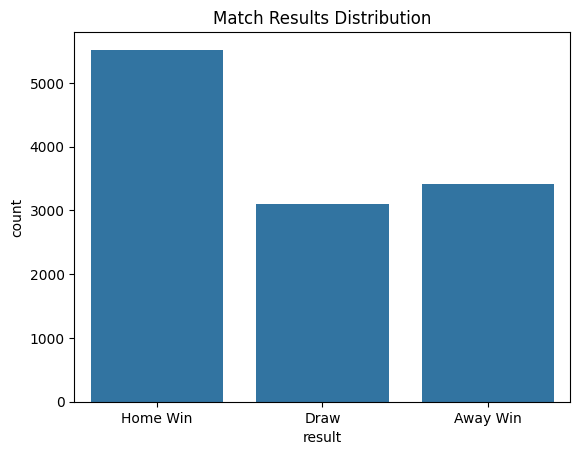

In [270]:
print(df['result'].value_counts())

sns.countplot(x='result', data=df)
plt.title("Match Results Distribution")
plt.show()

In [271]:
print("Average Goals per Match:", df['totalgoals'].mean())

Average Goals per Match: 2.666888408448362


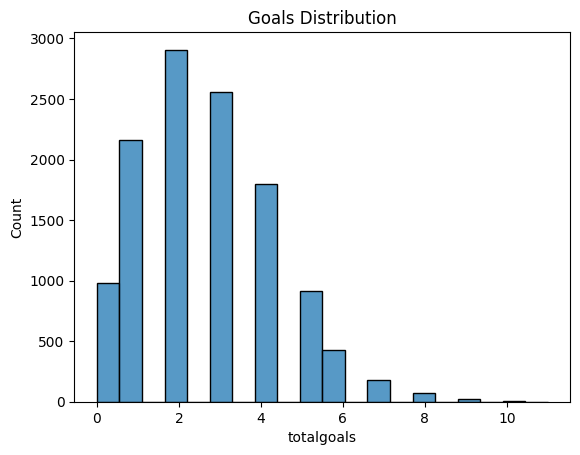

In [272]:
sns.histplot(df['totalgoals'], bins=20)
plt.title("Goals Distribution")
plt.show()

## How many times hometeam win & How many times awayteam win :

In [273]:
home_wins = df[df['result'] == 'Home Win']['home_team'].value_counts()
away_wins = df[df['result'] == 'Away Win']['away_team'].value_counts()
print(home_wins.head())
print(away_wins.head())

home_team
Manchester Utd    417
Arsenal           382
Liverpool         376
Chelsea           360
Tottenham         323
Name: count, dtype: int64
away_team
Manchester Utd     309
Chelsea            269
Arsenal            263
Liverpool          252
Manchester City    204
Name: count, dtype: int64


the most winner teams in the whole data :

In [274]:
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)
print(total_wins.head(10))

Manchester Utd     726
Arsenal            645
Chelsea            629
Liverpool          628
Tottenham          520
Manchester City    501
Everton            426
Newcastle Utd      401
Aston Villa        372
West Ham           346
Name: count, dtype: int64


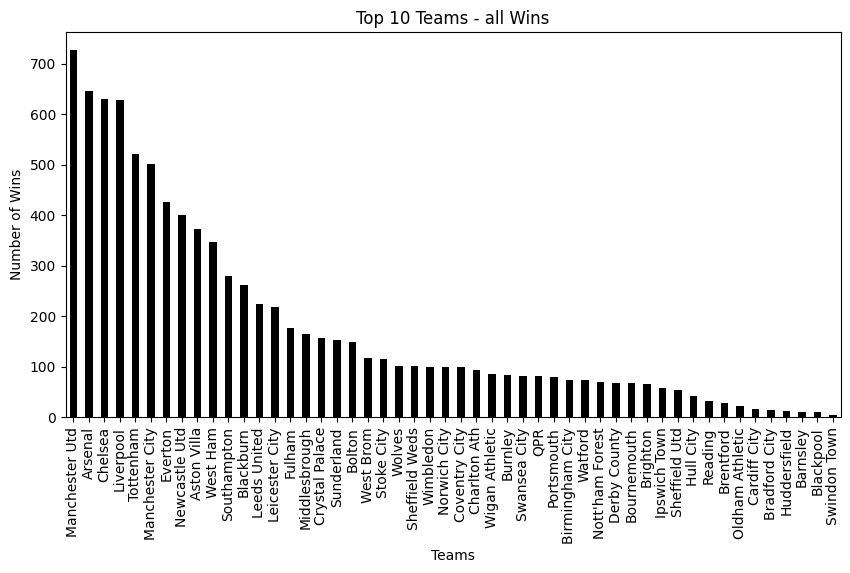

In [275]:
total_wins.plot(kind='bar', figsize=(10,5), color ='black')
plt.title("Top 10 Teams - all Wins")
plt.ylabel("Number of Wins")
plt.xlabel("Teams")
plt.show()

In [276]:
home_wins.head(10)

,count
home_team,
Manchester Utd,417
Arsenal,382
Liverpool,376
Chelsea,360
Tottenham,323
Manchester City,297
Everton,273
Newcastle Utd,264
West Ham,224


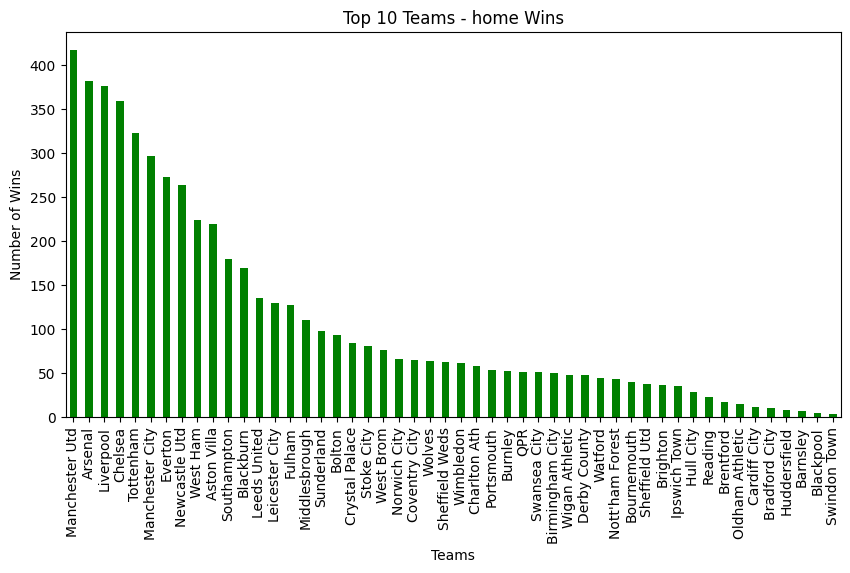

In [277]:
home_wins.plot(kind='bar', figsize=(10,5), color='green')
plt.title("Top 10 Teams - home Wins")
plt.ylabel("Number of Wins")
plt.xlabel("Teams")
plt.show()

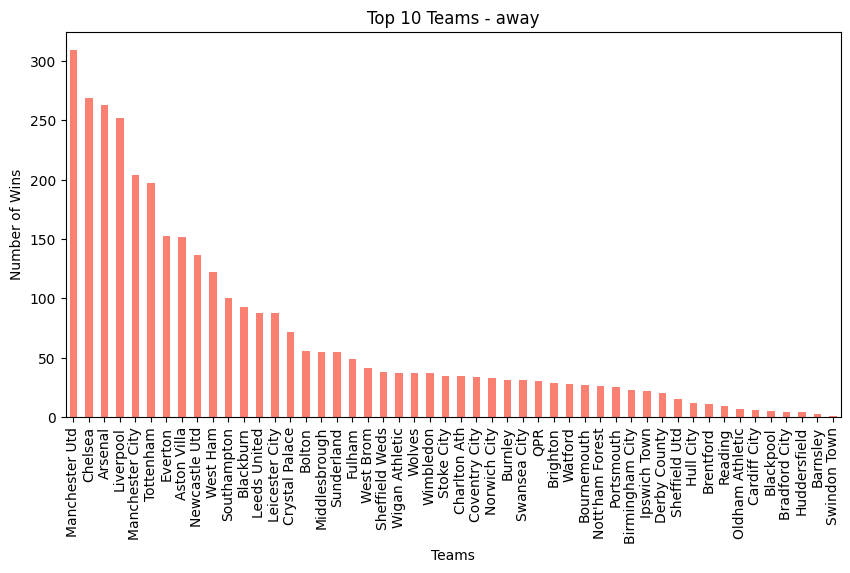

In [278]:
away_wins.plot(kind='bar', figsize=(10,5), color='salmon')
plt.title("Top 10 Teams - away")
plt.ylabel("Number of Wins")
plt.xlabel("Teams")
plt.show()

In [279]:
total_goals_teams = df.groupby('home_team')['totalgoals'].sum().sort_values(ascending=False)


In [280]:
total_goals_teams.head(10)

,totalgoals
home_team,
Arsenal,1721
Manchester Utd,1688
Liverpool,1677
Tottenham,1675
Chelsea,1645
Everton,1564
Manchester City,1492
Newcastle Utd,1472
West Ham,1415


In [281]:
avg_goals = df['totalgoals'].mean()
print("Average Goals per Match:", round(avg_goals,2))

Average Goals per Match: 2.67


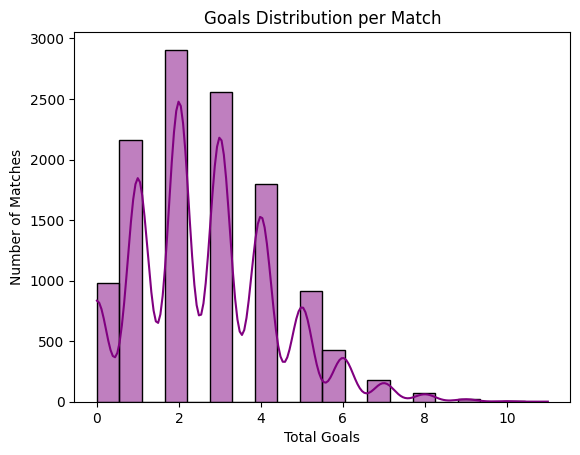

In [282]:
sns.histplot(df['totalgoals'], bins=20, kde=True, color='purple')
plt.title("Goals Distribution per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()